# lec 05: specialized functions from libraries

<font size = "2">
sept 15 2026

objectives:
- random library
- binomial function from scipy
- why well-written library functions like in scipy can succeed where a DIY calc fails

standard libraries (math, statistics, random) ship WITH python

third party libraries (pandas, numpy)are written by other people so you have to install them first
* anaconda comes with matplotlib and pandas auto installed

## random

In [11]:
import random

months = ["January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"]

print(len(months), "months in the list")
print(f"there are {len(months)} months in the list")

12 months in the list
there are 12 months in the list


`random.choice` takes a list and returns one randomly chosen element

In [12]:
random_month = random.choice(months)
print(random_month)

March


In [13]:
five_months = random.choices(months, k=5)
print(five_months)

# notice how there's two Decembers

['July', 'January', 'April', 'December', 'September']


`random.sample` chooses k items with no replacement

In [14]:
five_diff = random.sample(months, 5)
print(five_diff)

['February', 'January', 'April', 'May', 'November']


`random.sample` k items from a list of length k is just a `random.shuffle`

In [15]:
print(months)

shuffle_momths = random.shuffle(months)
print(shuffle_momths)

# 'none' because the function didn't assign it to anything

print(months)

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
None
['February', 'January', 'November', 'June', 'May', 'August', 'December', 'April', 'October', 'July', 'September', 'March']


`rand.int(a, b)` returns a random integer between a and b (inclusive); samples with replacement

In [16]:
num = random.randint(0,5)
print(num)

1


In [17]:
dice = random.randint(1,6)
print(dice)

3


we can make random repeatable with `random.seed` (i.e. get the same output by setting the seed to something fized)

essentially there's a deterministic algorithm using a seed that creates a pseudo-random outcome

In [18]:
random.seed(10)
print(random.choices(months, k=3))

['December', 'August', 'December']


In [19]:
random.seed(10) #setting seed doesnt make every call the same BUT each next row uses the same predictable pathway
print(random.choices(months, k=3)) 
print(random.choices(months, k=3))

['December', 'August', 'December']
['November', 'July', 'July']


In [20]:
random.seed(10)
print(random.choices(months, k=3)) 
print(random.choices(months, k=3))

['December', 'August', 'December']
['November', 'July', 'July']


best practice when setting a seed is to pick a number with a lot of digits -> less likely to choose the same number as someone else running the same reproducible simulation

## stats.binom:

imagine flipping a coin and counting how many times it comes up heads - the binomial distribution describes exactly this; given
- n = number coin flips
- p = probability of heads on any single flip

it tells us the probability of getting each possible number of heads (0, 1, 2, ..., n heads)

the probability of exactly k heads in n flips is

$$P(k \text{ heads}) = \frac{n!}{k!\,(n-k)!}\, p^{k}\,(1-p)^{n-k}$$

In [ ]:
# calculating coin flip probabilities
import math

n=10; k=5; p=0.5
probability = math.factorial(n) * (p ** k) * ((1 - p) ** (n - k)) / (math.factorial(k) * math.factorial(n - k))

print(f'The probability of getting {k} heads is {probability}')

'''
Note: Computing full factorials directly (math.factorial) for large numbers causes integer overflow in memory-constrained environments or performance slowdowns, while multiplying extremely small power floats leads to floating-point underflow that rounds the final result to zero.
'''

The probability of getting 5 heads is 0.24609375


scipy for mathematical functions:

scipy provides this as `stats.binom` / `stats.binom.pmf`! allows us to do for a much wider range of vals too

In [29]:
import scipy.stats as stats
probability = stats.binom.pmf(k, n, p)
print(f'The probability of getting {k} heads is {probability}')

The probability of getting 5 heads is 0.2460937500000002


can also get the whole distr:

[0.00097656 0.00976563 0.04394531 0.1171875  0.20507812 0.24609375
 0.20507812 0.1171875  0.04394531 0.00976563 0.00097656]


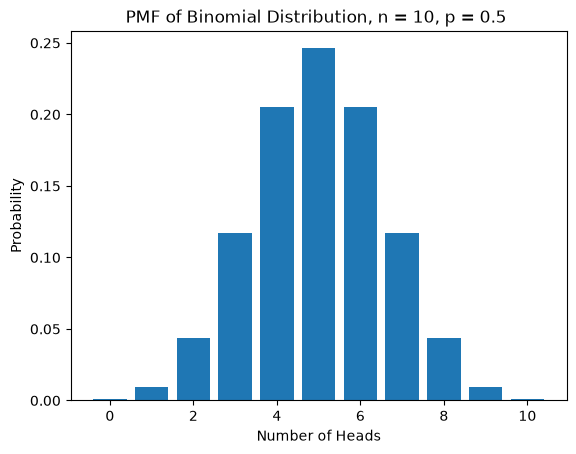

In [30]:
import matplotlib.pyplot as plt

n = 10 # number of flips
p = 0.5 # fair coin

possible_heads = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

pmf_vals = stats.binom.pmf(possible_heads, n, p)

print(pmf_vals)

plt.bar(possible_heads, pmf_vals)
plt.title(f"PMF of Binomial Distribution, n = {n}, p = {p} ")
plt.xlabel("Number of Heads")
plt.ylabel("Probability")
plt.show()


# numpy 

numpy arrays
- recall how "+" concatenates two lists
- numpy arrays actually will add!
    - primariy useful for storing numbers
    - all operations on arrays are numerical unlike lists
- numpy performs element-wise division, meaning each element $a_i$ is divided by the corresponding element $b_i$. 

np.linspace(start, stop, num)

np.arange(start, stop, step) # [start, stop)

In [22]:
import numpy as np

# most common way to make a numpy array is make a list and convert it
num_list = [5.6, 2.9, 9.7, -10, 0, 3]
num_array = np.array(num_list)

print(type(num_array))
print(num_array)
display(num_array)

<class 'numpy.ndarray'>
[  5.6   2.9   9.7 -10.    0.    3. ]


array([  5.6,   2.9,   9.7, -10. ,   0. ,   3. ])

In [23]:
list_1 = [2, 3, 5, 11]
list_2 = [1, -4, 2, 0]

# The "+" operation concatenates the lists
print(list_1 + list_2)

[2, 3, 5, 11, 1, -4, 2, 0]


In [24]:
array_1 = np.array([2, 3, 5, 11])
array_2 = np.array([1, -4, 2, 0])

# The "+" operation adds the elements of the two arrays together
print(array_1 + array_2)

[ 3 -1  7 11]


the + operation performs element-by-element addition between two arrays of the **same size**. mathematically, we view numpy arrays as *vectors*, specifically column vectors.

an example where both arrays/vectors have 4 elements:

$ a + b = \begin{pmatrix} a_1 \\ a_2 \\ a_3 \\ a_4 \end{pmatrix} +
          \begin{pmatrix} b_1 \\ b_2 \\ b_3 \\ b_4 \end{pmatrix} =
          \begin{pmatrix} a_1 + b_1 \\ a_2 + b_2 \\ a_3 + b_3 \\ a_4 + b_4 \end{pmatrix}$


u can also use the "+" operator with a numpy array and a single number:

$ a + 2 = \begin{pmatrix} a_1 \\ a_2 \\ a_3\end{pmatrix} + 2 = \begin{pmatrix} a_1 + 2 \\ a_2 + 2 \\ a_3 + 2\end{pmatrix}$

In [32]:
a = np.array([3, 11, -2.2])
print(a + 2)

[ 5.  13.  -0.2]


this definition extends to other operators:

In [33]:
# log(x) computes the logarithm with base "e"; same as ln(x)

# exp(x) compute Euler's number raised to the power of "x"

# sin(x) computes the sine of x (in radians)

# cos(x) computes the cosine of x (in radians)

# In this example, we're substituting x = 2

print(np.log(2))
print(np.exp(2))
print(np.sin(2))
print(np.cos(2))
print(np.sqrt(2))

0.6931471805599453
7.38905609893065
0.9092974268256817
-0.4161468365471424
1.4142135623730951


In [34]:
# also comes with built-in constaants like
print(np.pi)
print(np.e)
print(np.exp(1))

3.141592653589793
2.718281828459045
2.718281828459045


plotting functions using numpy arrays:
- very convenient bc we can use them in math expressions too

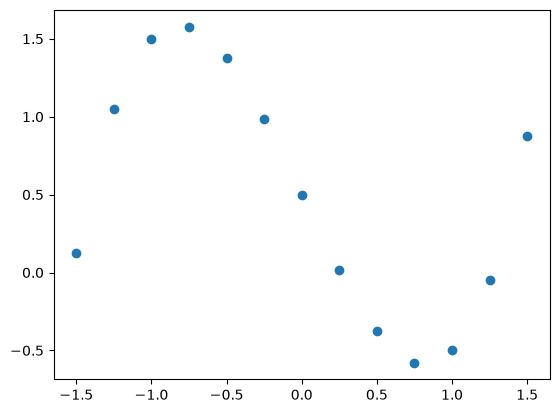

In [39]:
# can also do x_vals = np.arange(-1.5, 1.51, 0.25)
# but making a list just as a point
x_vals = [-1.5, -1.25, -1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5]

# convert to numpy array
x_vals = np.array(x_vals)
y_vals = x_vals**3 - 2*x_vals + 0.5

plt.scatter(x = x_vals, y = y_vals)
plt.show()

## exercises

**Q1:** in the cell below, a list "days" is defined containing the seven days of the week. you want to schedule office hours by appointment with your professor. yhe list "free_days" contains the days that your professor is available.

- randomly select one of the days of the week in the list "days" using the `random` library. assign it to a variable called "proposed_day". 

- create a boolean variable called "is_free" that has the value `True` if the professor is available on the randomly selected day, and `False` otherwise.

- print the values of "proposed_day" and "is_free" to the screen.

In [25]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

free_days = ["Monday", "Thursday", "Friday"]

proposed_day = random.choice(days)

is_free = proposed_day in free_days

print(proposed_day)
print(is_free)

Friday
True


**Q2:** imagine flipping a coin repeatedly until we get 10 heads (in total, not in a row). How many tails will you see before seeing the 10th head?

the **negative binomial distribution** describes exactly this. given
- `n` = the number of heads needed to stop the experiment, and
- `p` = the probability of heads on a single flip,

it tells us the probability of getting each possible number of tails before the experiment ends (0 tails, 1 tail, 2 tails, ... ).


the probability of exactly `k` tails before seeing `n` heads is
$$P(k \text{ tails}) = \frac{(k+n-1)!}{k!\,(n-1)!}\, p^{k}\,(1-p)^{n}$$

use the scipy function `scipy.stats.nbinom` to plot the probability mass function over the range $k=0, 1, 2, ..., 9, 10$ when we stop after flipping $n=10$ heads of a fair coin (so $p = 0.5$).


[0.00097656 0.00488281 0.01342773 0.02685547 0.04364014 0.06109619
 0.07637024 0.08728027 0.09273529 0.09273529 0.08809853]


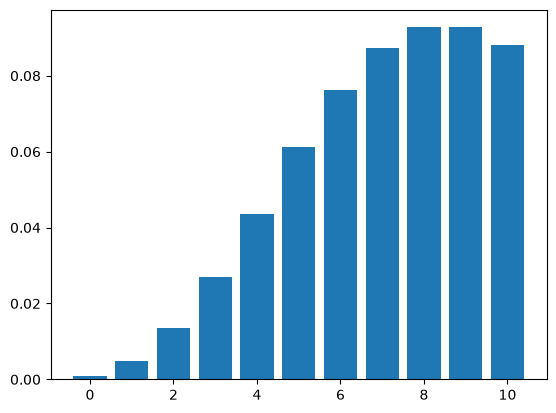

In [ ]:
n = 10; p = 0.5
possible_heads = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
pmf_vals = stats.nbinom.pmf(possible_heads, n, p)

print(pmf_vals)

plt.bar(possible_heads, pmf_vals)
plt.show()

**Q3:** how should we calculate the following in python?

$$ \frac{27}{12 - 3} = \frac{27}{9} = 3$$

$$ (5 + 3)\cdot 2 = 8 \cdot 2 = 16$$

$$ 5\cdot 3 + 2\cdot 4 = 15 + 8 = 23$$

$$ \frac{(5 + 3)\cdot 2}{4} = \frac{16}{4} = 4$$

In [48]:
print(27 / (12-3))

print((5+3)*2)

print(5*3 + 2*4)

print(((5+3)*2)/4)

3.0
16
23
4.0


**Q4** using numpy, do the following:

- define a variable $x = 0.5$

- compute the value of $\pi x^2$ (ensure it prints to the screen)

- compute the value of $\dfrac{1}{\sqrt{2\pi}}\mathrm{e}^{-x^2}$ (print to the screen)

- compute the value of $\ln\big(\dfrac{2x + 1}{x + 2}\big)$ (print to the screen)

In [52]:
x = 0.5
print(np.pi * x**2)
print((np.exp(-x**2))/(np.sqrt(2*np.pi)))
print(np.log((2*x+1)/(x+2)))

0.7853981633974483
0.3106965603769278
-0.2231435513142097


**Q5:** the code cell below defines two vectors

$a = \begin{pmatrix} a_1\\a_2\\a_3\end{pmatrix},\quad b = \begin{pmatrix} b_1\\b_2\\b_3\end{pmatrix}$

in one line of code each, define the following vectors:

$c = \begin{pmatrix} a_1\cdot b_1\\ a_2 \cdot b_2 \\ a_3 \cdot b_3 \end{pmatrix}, \quad d = \begin{pmatrix} 5 - a_1\\ 5 - a_2 \\ 5 - a_3 \end{pmatrix},\quad e = \begin{pmatrix} (a_1 - b_1)/2 \\ (a_2 - b_2)/2 \\ (a_3 - b_3)/2\end{pmatrix}$

$f = \begin{pmatrix} b_1^{a_1}\\ b_2^{a_2} \\ b_3^{a_3} \end{pmatrix},\quad g = \begin{pmatrix} 2^{a_1}\\ 2^{a_2} \\ 2^{a_3}\end{pmatrix},\quad h = \begin{pmatrix} \mathrm{e}^{a_1 + b_1} \\ \mathrm{e}^{a_2 + b_2} \\ \mathrm{e}^{a_3 + b_3} \end{pmatrix}$

try to extend the vector operations you saw above

In [54]:
a = np.array([2, 1.2, 3.4])
b = np.array([2.2, -3, 10.01])
c = a*b
d = 5-a
e = (a-b)/2
f = b**a
g = 2**a
h = np.exp(a+b)

/var/folders/7q/7r1pkdyx07g6795dl8b86cs80000gp/T/ipykernel_14699/1883879249.py:6: RuntimeWarning: invalid value encountered in power
  f = b**a


**Q6** in the cell below, two arrays are created:

$a = \begin{pmatrix} a_1\\a_2\\a_3\\a_4\end{pmatrix},\quad b = \begin{pmatrix} b_1\\b_2\\b_3\\b_4\end{pmatrix}$

define a new array

$c = \begin{pmatrix} a_1/b_1\\ a_2/b_2\\ a_3/b_3\\a_4/b_4\end{pmatrix}$

and print its value to the screen. what do you see? can you explain the reason for it?


In [ ]:
a = np.array([0, 1.0, np.pi, np.cos(np.pi/12)])
b = np.array([0, 2.0, 4, 0])

c = a/b
print(c)

# div by 0

[       nan 0.5        0.78539816        inf]


/var/folders/7q/7r1pkdyx07g6795dl8b86cs80000gp/T/ipykernel_14699/4218816758.py:4: RuntimeWarning: divide by zero encountered in divide
  c = a/b
/var/folders/7q/7r1pkdyx07g6795dl8b86cs80000gp/T/ipykernel_14699/4218816758.py:4: RuntimeWarning: invalid value encountered in divide
  c = a/b


**Q7** using numpy arrays, create a scatter plot of the function

$$q(x) = \sin(\pi x) + 1$$

 at a set of points in the interval $0 \leq x \leq 2$

<function matplotlib.pyplot.show(close=None, block=None)>

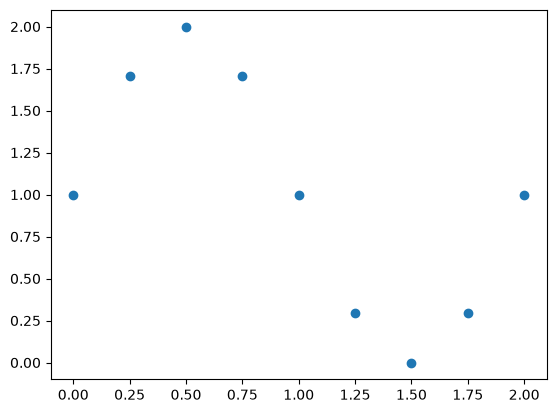

In [64]:
x_val = np.linspace(0, 2, 9)
y_val = np.sin(np.pi * x_val) + 1

plt.scatter(x_val, y_val)
plt.show

**Q8** using numpy arrays, create a scatter plot of the function $f(g(t))$, where

$$ f(x) = x^2 - 5x + 2 $$

$$ g(t) = \sin(t + 3) $$

at a set of points in the interval $2\pi \leq x \leq 4\pi$

<function matplotlib.pyplot.show(close=None, block=None)>

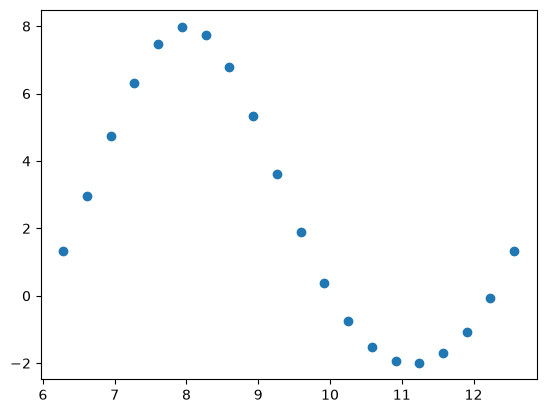

In [73]:
t = np.linspace(2*np.pi, 4*np.pi, 20)
x = np.sin(t+3)
f = x**2 - 5*x + 2

plt.scatter(t, f)
plt.show